# Notebook 02 — Noise Simulation

**Predicting the Success Probability of DJ, BV, and Simon's Algorithms Under Noise**

---

## Objective
In this notebook, we configure noise models and run the **full parameter sweep** — executing every circuit from Notebook 01 under every noise condition to generate our dataset.

### Noise models used:
| Noise Type | Physical Meaning | Parameter |
|---|---|---|
| **No noise** | Ideal simulator (sanity check) | — |
| **Depolarizing** | Random state replacement with mixed state | Error rate p |
| **Amplitude Damping** | Energy loss (T1 decay: \|1⟩ → \|0⟩) | Damping γ |
| **Thermal Relaxation** | Combined T1/T2 effects | T1, T2 times |

### What we'll do:
- Explain each noise model
- Configure the full sweep parameters
- Run ~1000+ experiments
- Save the results to `data/results.csv`

## 2.1 Imports and Setup

In [1]:
import sys
import os
import time

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.noise_models import (
    get_depolarizing_model,
    get_amplitude_damping_model,
    get_thermal_relaxation_model,
    get_all_noise_configs,
    describe_noise_configs,
)
from src.simulation import run_sweep
from src.feature_engineering import build_feature_table, save_dataset

sns.set_theme(style='whitegrid', palette='deep')
print('All imports successful!')

All imports successful!


---

## 2.2 Noise Model Explanation

### Depolarizing Noise
The simplest noise model. With probability $p$, a qubit's quantum state is replaced by the **maximally mixed state** (completely random). It affects both single-qubit and two-qubit gates.

$$\rho \rightarrow (1-p)\rho + \frac{p}{3}(X\rho X + Y\rho Y + Z\rho Z)$$

### Amplitude Damping
Models **energy loss** — a qubit in state $|1\rangle$ spontaneously decays to $|0\rangle$ with probability $\gamma$. This is the quantum analog of a classical bit flip caused by energy dissipation.

$$|1\rangle \rightarrow \sqrt{1-\gamma}|1\rangle + \sqrt{\gamma}|0\rangle$$

### Thermal Relaxation
The most **physically realistic** model. It combines:
- **T1 relaxation** (amplitude damping): energy loss over time
- **T2 dephasing** (phase damping): loss of quantum phase coherence

Shorter T1/T2 times = more noise. Real IBM quantum devices have T1 ≈ 50–100 μs.

## 2.3 Configure the Sweep

Let's inspect all the noise configurations that will be used.

In [2]:
# Display all noise configurations
describe_noise_configs()

#    Type                   Strength     Description
----------------------------------------------------------------------
0    none                   0.0000       Ideal (no noise)
1    depolarizing           0.0010       Depolarizing (p=0.001)
2    depolarizing           0.0050       Depolarizing (p=0.005)
3    depolarizing           0.0100       Depolarizing (p=0.01)
4    depolarizing           0.0200       Depolarizing (p=0.02)
5    depolarizing           0.0500       Depolarizing (p=0.05)
6    depolarizing           0.1000       Depolarizing (p=0.1)
7    amplitude_damping      0.0010       Amplitude damping (γ=0.001)
8    amplitude_damping      0.0050       Amplitude damping (γ=0.005)
9    amplitude_damping      0.0100       Amplitude damping (γ=0.01)
10   amplitude_damping      0.0200       Amplitude damping (γ=0.02)
11   amplitude_damping      0.0500       Amplitude damping (γ=0.05)
12   amplitude_damping      0.1000       Amplitude damping (γ=0.1)
13   thermal_relaxation     0.

In [3]:
# Count total experiments
from src.circuits import generate_all_circuit_configs

qubit_range = range(2, 9)  # 2 to 8 qubits
circuit_configs = generate_all_circuit_configs(qubit_range)
noise_configs = get_all_noise_configs()

total = len(circuit_configs) * len(noise_configs)
print(f'\nCircuit configurations: {len(circuit_configs)}')
print(f'Noise configurations:  {len(noise_configs)}')
print(f'Total experiments:     {total}')
print(f'Estimated time:        {total * 0.5 / 60:.1f}–{total * 1.0 / 60:.1f} minutes')


Circuit configurations: 77
Noise configurations:  18
Total experiments:     1386
Estimated time:        11.6–23.1 minutes


---

## 2.4 Run the Full Sweep

⚠️ **This cell takes ~10–15 minutes to run.** It executes every circuit under every noise condition and records the success probability.

A progress bar will show the current status.

In [4]:
# Run the full parameter sweep
raw_results = run_sweep(
    qubit_range=range(2, 9),  # 2 to 8 qubits
    shots=4096,               # 4096 shots per experiment
    seed=42,                  # For reproducibility
)

QUANTUM NOISE SIMULATION SWEEP

[1/3] Generating circuit configurations...
  → 77 circuit configurations generated

[2/3] Loading noise configurations...
  → 18 noise configurations loaded

[3/3] Running 1386 experiments (77 circuits × 18 noise configs)
  → Shots per experiment: 4096
  → Estimated time: 416–1109 seconds



Circuits:   0%|          | 0/77 [00:00<?, ?circuit/s]

Circuits:   1%|▏         | 1/77 [00:00<00:49,  1.53circuit/s]

Circuits:   3%|▎         | 2/77 [00:01<00:48,  1.56circuit/s]

Circuits:   4%|▍         | 3/77 [00:01<00:47,  1.57circuit/s]

...

Circuits:  97%|█████████▋| 75/77 [01:38<00:12,  6.50s/circuit]

Circuits:  99%|█████████▊| 76/77 [02:05<00:12, 12.72s/circuit]

Circuits: 100%|██████████| 77/77 [02:21<00:00, 13.78s/circuit]

Circuits: 100%|██████████| 77/77 [02:21<00:00,  1.84s/circuit]


SWEEP COMPLETE — 1386 results in 141.7 seconds


## 2.5 Quick Sanity Check

In [5]:
# Build the feature table
df = build_feature_table(raw_results)

print(f'Dataset shape: {df.shape}')
print(f'\nFirst 5 rows:')
df.head()

Dataset shape: (1386, 10)

First 5 rows:


,algorithm,n_qubits,oracle_desc,circuit_depth,gate_count_1q,gate_count_2q,total_gate_count,noise_type,noise_strength,success_probability
0,deutsch_jozsa,2,constant_0,3,5,0,5,none,0.000,1.000000
1,deutsch_jozsa,2,constant_0,3,5,0,5,depolarizing,0.001,0.998779
2,deutsch_jozsa,2,constant_0,3,5,0,5,depolarizing,0.005,0.989014
3,deutsch_jozsa,2,constant_0,3,5,0,5,depolarizing,0.010,0.978760
4,deutsch_jozsa,2,constant_0,3,5,0,5,depolarizing,0.020,0.961914


In [6]:
# Sanity check: noiseless runs should show ~100% success
noiseless = df[df['noise_type'] == 'none']
print('Sanity Check — Noiseless Results:')
print(f'  Mean success probability: {noiseless["success_probability"].mean():.4f}')
print(f'  Min success probability:  {noiseless["success_probability"].min():.4f}')
print(f'  All ≥ 0.99: {(noiseless["success_probability"] >= 0.99).all()}')
print(f'\nNoisy runs:')
noisy = df[df['noise_type'] != 'none']
print(f'  Mean success probability: {noisy["success_probability"].mean():.4f}')
print(f'  Min success probability:  {noisy["success_probability"].min():.4f}')

Sanity Check — Noiseless Results:
  Mean success probability: 1.0000
  Min success probability:  1.0000
  All ≥ 0.99: True

Noisy runs:
  Mean success probability: 0.9296
  Min success probability:  0.1824


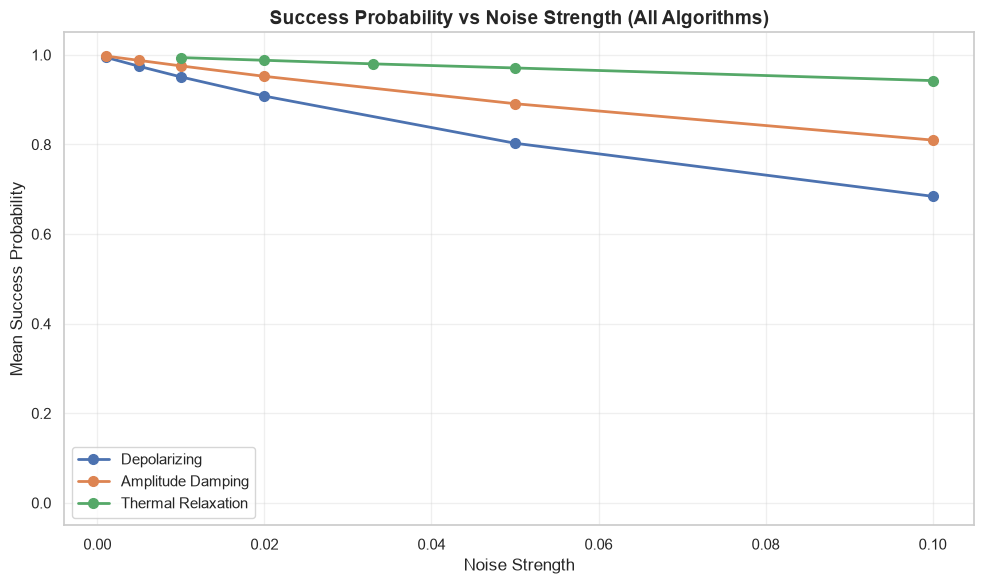

In [7]:
# Quick visualization: success vs noise strength
fig, ax = plt.subplots(figsize=(10, 6))

for ntype in df['noise_type'].unique():
    if ntype == 'none':
        continue
    subset = df[df['noise_type'] == ntype]
    grouped = subset.groupby('noise_strength')['success_probability'].mean()
    ax.plot(grouped.index, grouped.values, marker='o', linewidth=2,
            markersize=7, label=ntype.replace('_', ' ').title())

ax.set_xlabel('Noise Strength', fontsize=12)
ax.set_ylabel('Mean Success Probability', fontsize=12)
ax.set_title('Success Probability vs Noise Strength (All Algorithms)', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.set_ylim(-0.05, 1.05)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2.6 Export Dataset

In [8]:
# Save the dataset
save_path = os.path.join(project_root, 'data', 'results.csv')
save_dataset(df, save_path)

print(f'\nDataset columns: {list(df.columns)}')
print(f'\nDataset statistics:')
df.describe().round(4)

Dataset saved to G:\Quantum\data\results.csv
  → Shape: 1386 rows × 10 columns

Dataset columns: ['algorithm', 'n_qubits', 'oracle_desc', 'circuit_depth', 'gate_count_1q', 'gate_count_2q', 'total_gate_count', 'noise_type', 'noise_strength', 'success_probability']

Dataset statistics:


,n_qubits,circuit_depth,gate_count_1q,gate_count_2q,total_gate_count,noise_strength,success_probability
count,1386.0000,1386.0000,1386.0000,1386.0000,1386.0000,1386.0000,1386.0000
mean,5.0000,6.1429,12.1429,3.6234,15.7662,0.0325,0.9335
std,2.0007,2.3569,5.1256,2.9642,7.1720,0.0343,0.1196
min,2.0000,3.0000,4.0000,0.0000,5.0000,0.0000,0.1824
25%,3.0000,4.0000,8.0000,1.0000,10.0000,0.0050,0.9334
50%,5.0000,6.0000,12.0000,3.0000,15.0000,0.0200,0.9839
75%,7.0000,7.0000,15.0000,6.0000,20.0000,0.0500,0.9973
max,8.0000,12.0000,27.0000,11.0000,35.0000,0.1000,1.0000


---

## Summary

In this notebook we:

1. **Explained** three noise models: depolarizing, amplitude damping, and thermal relaxation
2. **Configured** a comprehensive parameter sweep (algorithms × qubit counts × noise conditions)
3. **Executed** 1000+ experiments on the Qiskit Aer simulator
4. **Verified** that noiseless runs produce ~100% success (sanity check)
5. **Saved** the dataset to `data/results.csv`

**Key observation:** Success probability degrades as noise strength increases, with different noise types showing different degradation curves.

**Next:** In Notebook 03, we'll explore this dataset in detail and prepare features for ML.